# Task 1: Data Preprocessing and Exploratory Data Analysis

**Objective:** Load, clean, and explore historical financial data for three assets (TSLA, BND, SPY) to prepare for time-series forecasting and portfolio optimization.

**Assets under analysis:**
- **TSLA** — Tesla Inc. (high-growth, high-volatility stock)
- **BND** — Vanguard Total Bond Market ETF (low-risk bond fund)
- **SPY** — S&P 500 ETF (broad US market benchmark)

**Date range:** January 1, 2015 — June 30, 2026

## 1. Setup and Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data_loader import (
    fetch_stock_data,
    extract_close_prices,
    clean_data,
    get_missing_report,
    calculate_daily_returns
)
from src.eda_utils import (
    plot_closing_prices,
    plot_normalized_prices,
    plot_daily_returns,
    plot_return_distributions,
    plot_rolling_statistics,
    detect_outliers,
    plot_outliers
)
from src.stationarity import run_adf_for_all
from src.risk_metrics import calculate_var, calculate_sharpe_ratio

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("All imports successful!")

All imports successful!


## 2. Data Extraction

In [2]:
tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-06-30"

raw_data = fetch_stock_data(tickers, start_date, end_date)
raw_data.head()

[*********************100%***********************]  3 of 3 completed

[INFO] Downloaded data shape: (2888, 15)
[INFO] Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00


Price           Close                              High              \
Ticker            BND         SPY       TSLA        BND         SPY   
Date                                                                  
2015-01-02  59.205654  169.687820  14.620667  59.234308  170.885549   
2015-01-05  59.377583  166.623322  14.006000  59.399072  168.812251   
2015-01-06  59.549545  165.053970  14.085333  59.728631  167.449404   
2015-01-07  59.585312  167.110672  14.063333  59.656945  167.449340   
2015-01-08  59.492229  170.076065  14.041333  59.535208  170.290837   

Price                        Low                              Open  \
Ticker           TSLA        BND         SPY       TSLA        BND   
Date                                                                 
2015-01-02  14.883333  59.040893  168.655304  14.217333  59.048058   
2015-01-05  14.433333  59.241476  166.317701  13.810667  59.270130   
2015-01-06  14.280000  59.477912  164.260992  13.614000  59.477912   
2015-01-07  14.318667  59.492189  165.929480  13.985333  59.556658   
2015-01-08  14.253333  59.434921  168.498390  14.000667  59.535208   

Price                               Volume                       
Ticker             SPY       TSLA      BND        SPY      TSLA  
Date                                                             
2015-01-02  170.472543  14.858000  2218800  121465900  71466000  
2015-01-05  168.647051  14.303333  5820100  169632600  80527500  
2015-01-06  166.929011  14.004000  3887600  209151400  93928500  
2015-01-07  166.375521  14.223333  2433400  125346700  44526000  
2015-01-08  168.514901  14.187333  1873400  147217800  51637500

In [3]:
close_prices = extract_close_prices(raw_data, tickers)
print(f"Close prices shape: {close_prices.shape}")
close_prices.head()

Close prices shape: (2888, 3)


Ticker,TSLA,BND,SPY
Date,,,
2015-01-02,14.620667,59.205654,169.687820
2015-01-05,14.006000,59.377583,166.623322
2015-01-06,14.085333,59.549545,165.053970
2015-01-07,14.063333,59.585312,167.110672
2015-01-08,14.041333,59.492229,170.076065


## 3. Data Cleaning and Understanding

In [4]:
print("DESCRIPTIVE STATISTICS — CLOSING PRICES")
print("=" * 50)
close_prices.describe()

DESCRIPTIVE STATISTICS — CLOSING PRICES


Ticker,TSLA,BND,SPY
count,2888.000000,2888.000000,2888.000000
mean,148.773923,66.281145,351.505532
std,138.895957,4.700144,155.443934
min,9.578000,58.531757,154.161636
25%,18.393499,62.268003,223.546818
50%,133.437668,65.507393,312.817917
75%,251.925831,70.451475,432.806824
max,489.880005,74.581291,757.618225


In [5]:
print("DATA TYPES:")
print(close_prices.dtypes)
print()
print(f"Index type: {type(close_prices.index).__name__}")
close_prices.info()

DATA TYPES:
Ticker
TSLA    float64
BND     float64
SPY     float64
dtype: object

Index type: DatetimeIndex
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TSLA    2888 non-null   float64
 1   BND     2888 non-null   float64
 2   SPY     2888 non-null   float64
dtypes: float64(3)
memory usage: 90.2 KB


In [6]:
print("MISSING VALUES REPORT:")
print("=" * 50)
missing_report = get_missing_report(close_prices)
print(missing_report)
print(f"\nTotal rows: {len(close_prices)}")

MISSING VALUES REPORT:
        Missing Count  Missing %
Ticker                          
TSLA                0        0.0
BND                 0        0.0
SPY                 0        0.0

Total rows: 2888


In [7]:
close_prices_clean = clean_data(close_prices)

[INFO] Missing values — before: 0, after: 0


In [8]:
daily_returns = calculate_daily_returns(close_prices_clean)
print(f"Daily returns shape: {daily_returns.shape}")
print()
print("DAILY RETURNS STATISTICS:")
daily_returns.describe()

Daily returns shape: (2887, 3)

DAILY RETURNS STATISTICS:


Ticker,TSLA,BND,SPY
count,2887.000000,2887.000000,2887.000000
mean,0.001803,0.000080,0.000573
std,0.036018,0.003346,0.011121
min,-0.210628,-0.054384,-0.109424
25%,-0.016643,-0.001511,-0.003700
50%,0.001216,0.000134,0.000656
75%,0.019456,0.001773,0.005930
max,0.226900,0.042200,0.105019


## 4. Exploratory Data Analysis

### 4.1 Closing Price Trends

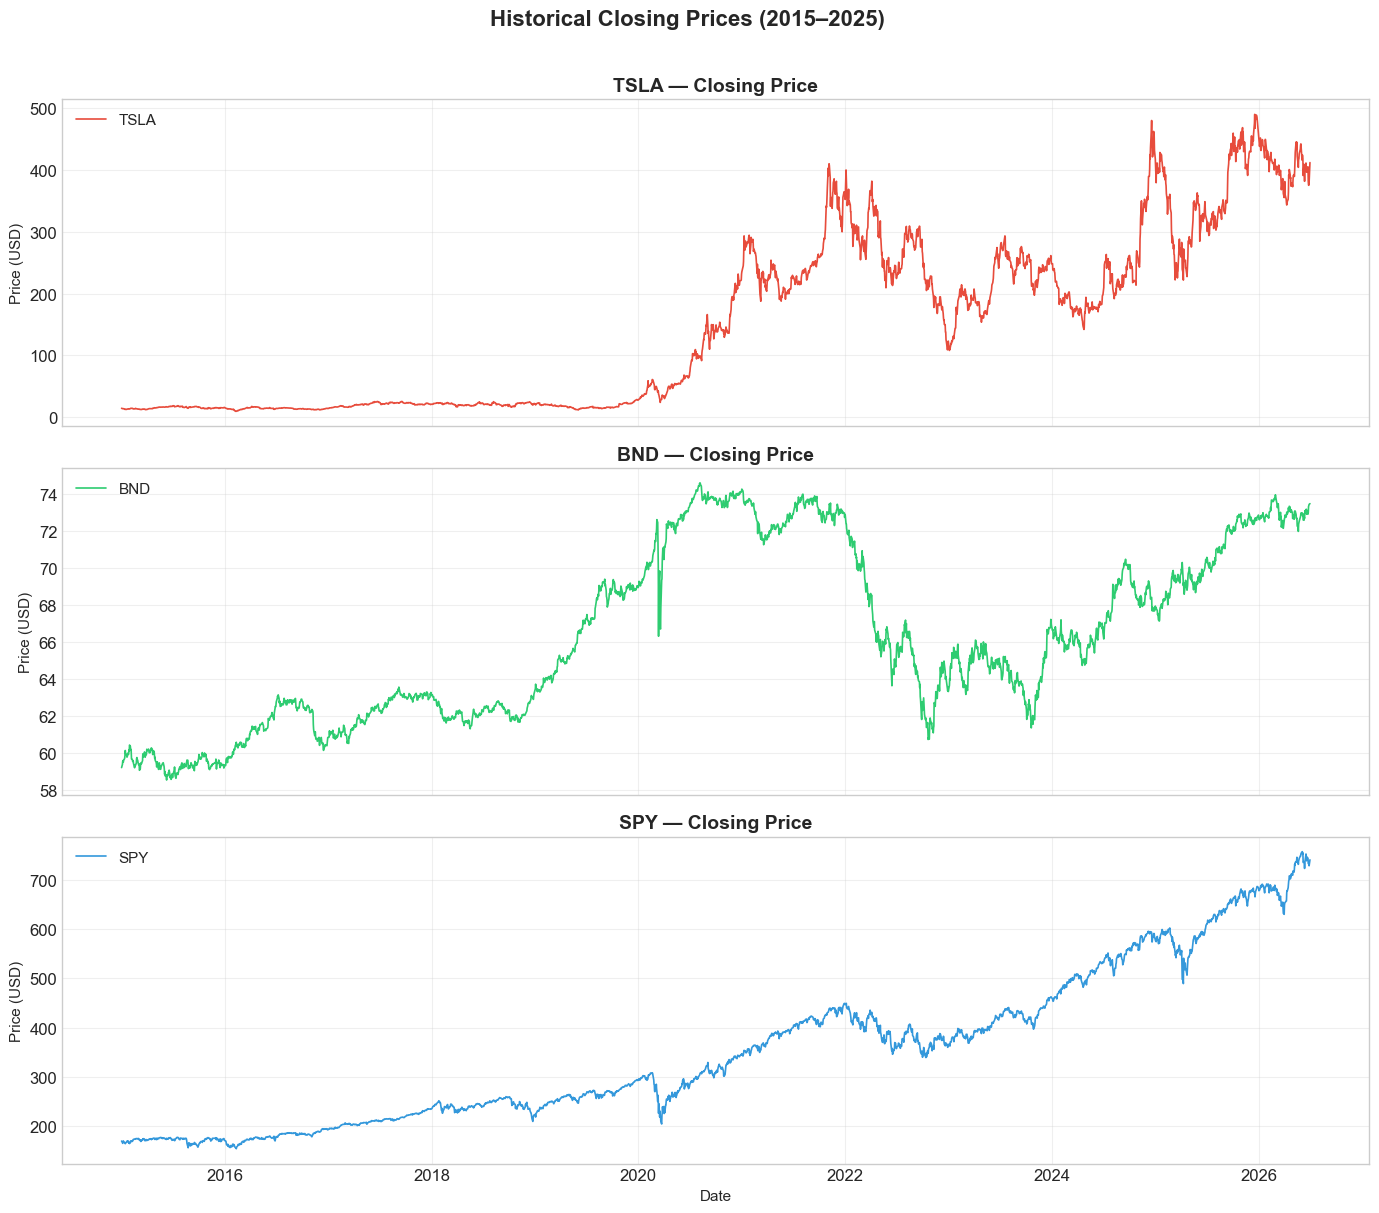

In [9]:
plot_closing_prices(close_prices_clean, tickers)

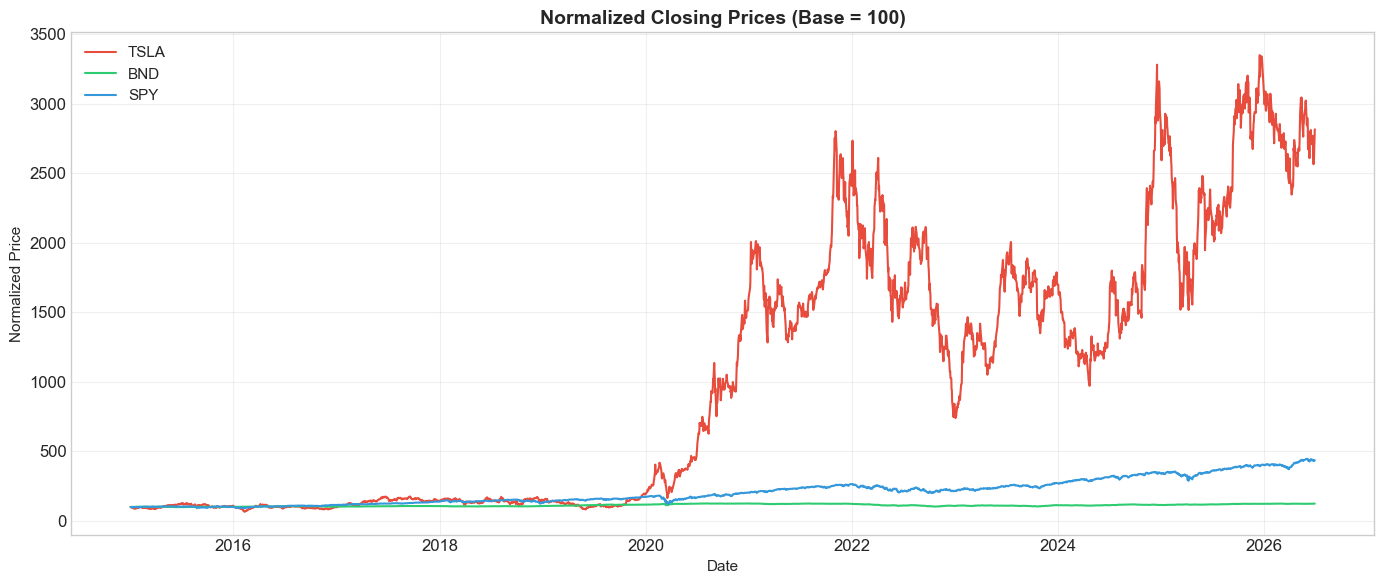

In [10]:
plot_normalized_prices(close_prices_clean, tickers)

### 4.2 Daily Returns Analysis

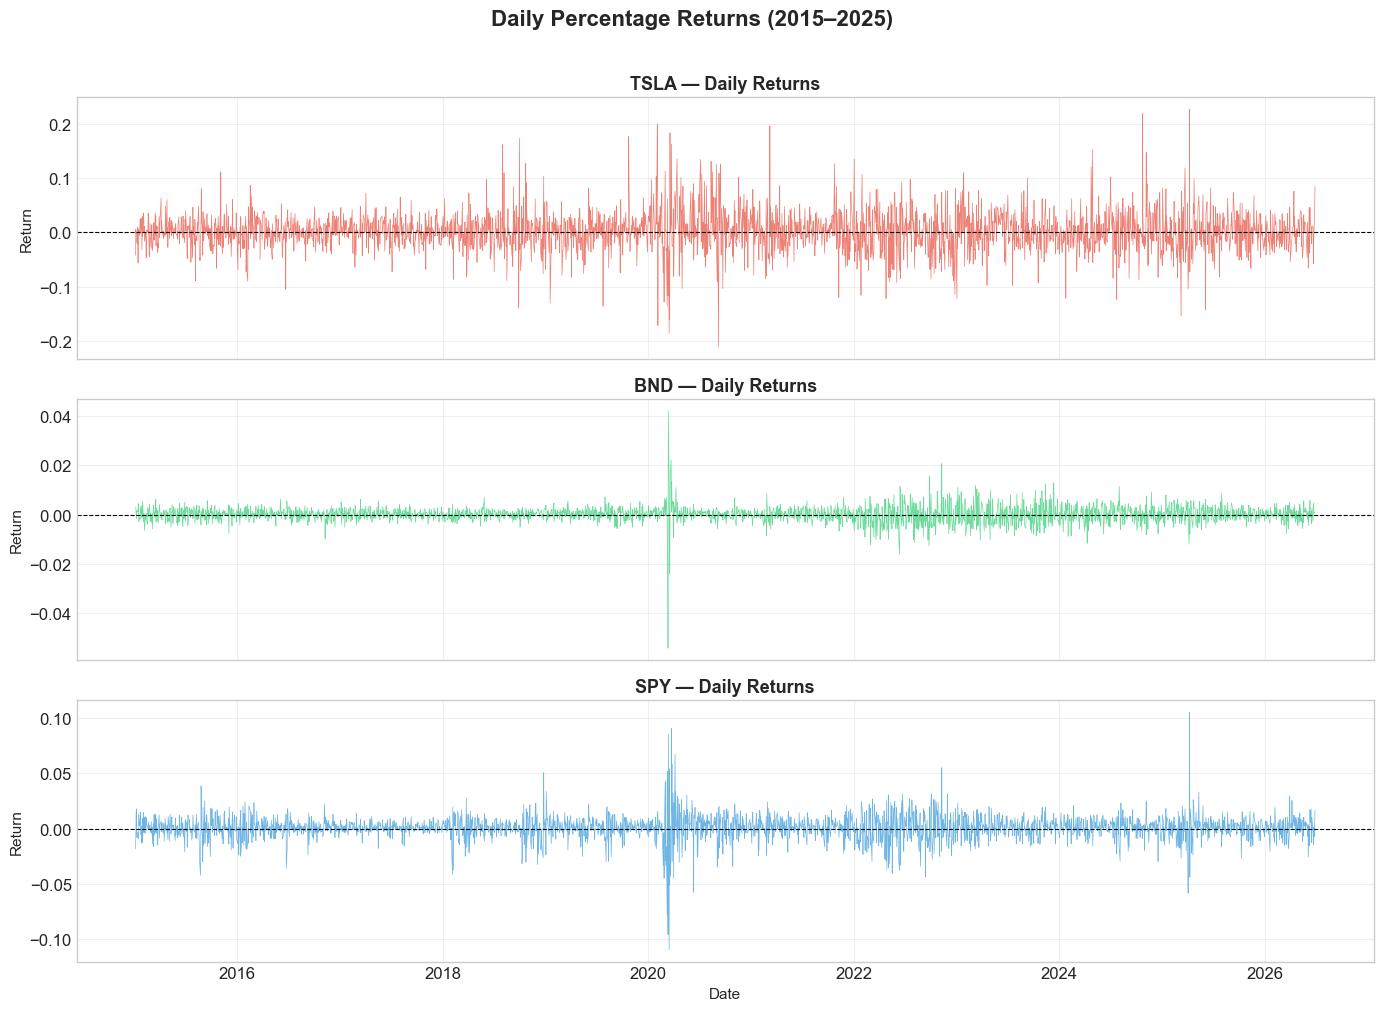

In [11]:
plot_daily_returns(daily_returns, tickers)

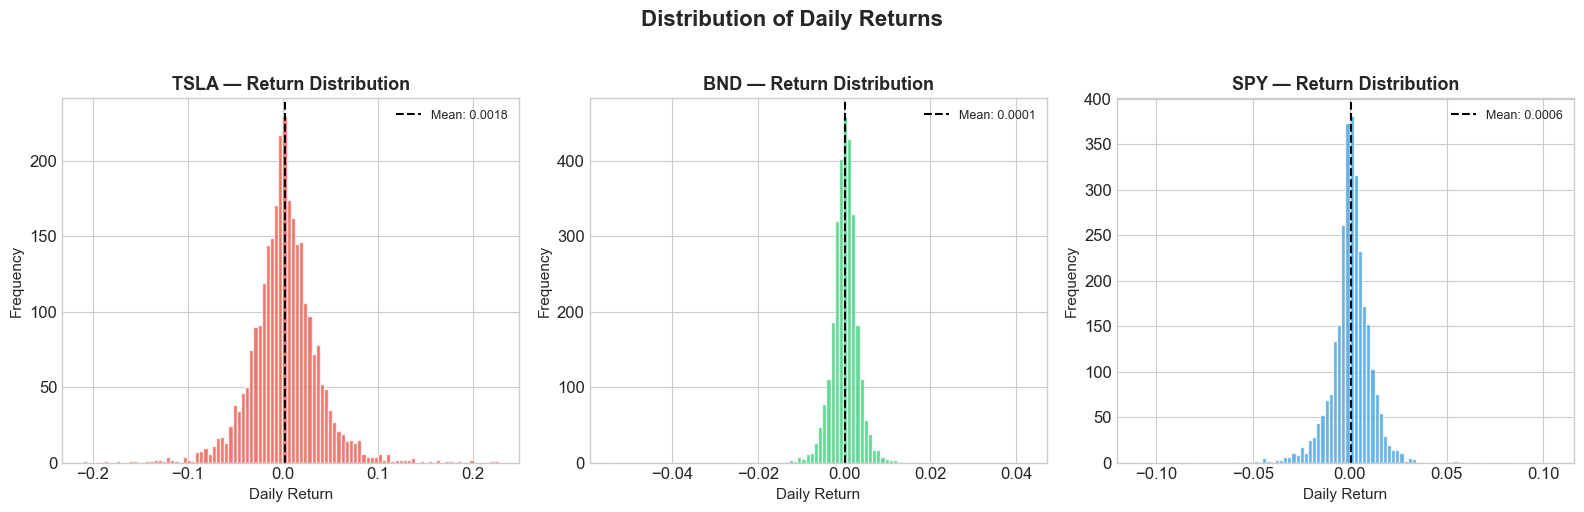

In [12]:
plot_return_distributions(daily_returns, tickers)

### 4.3 Volatility Analysis — Rolling Statistics

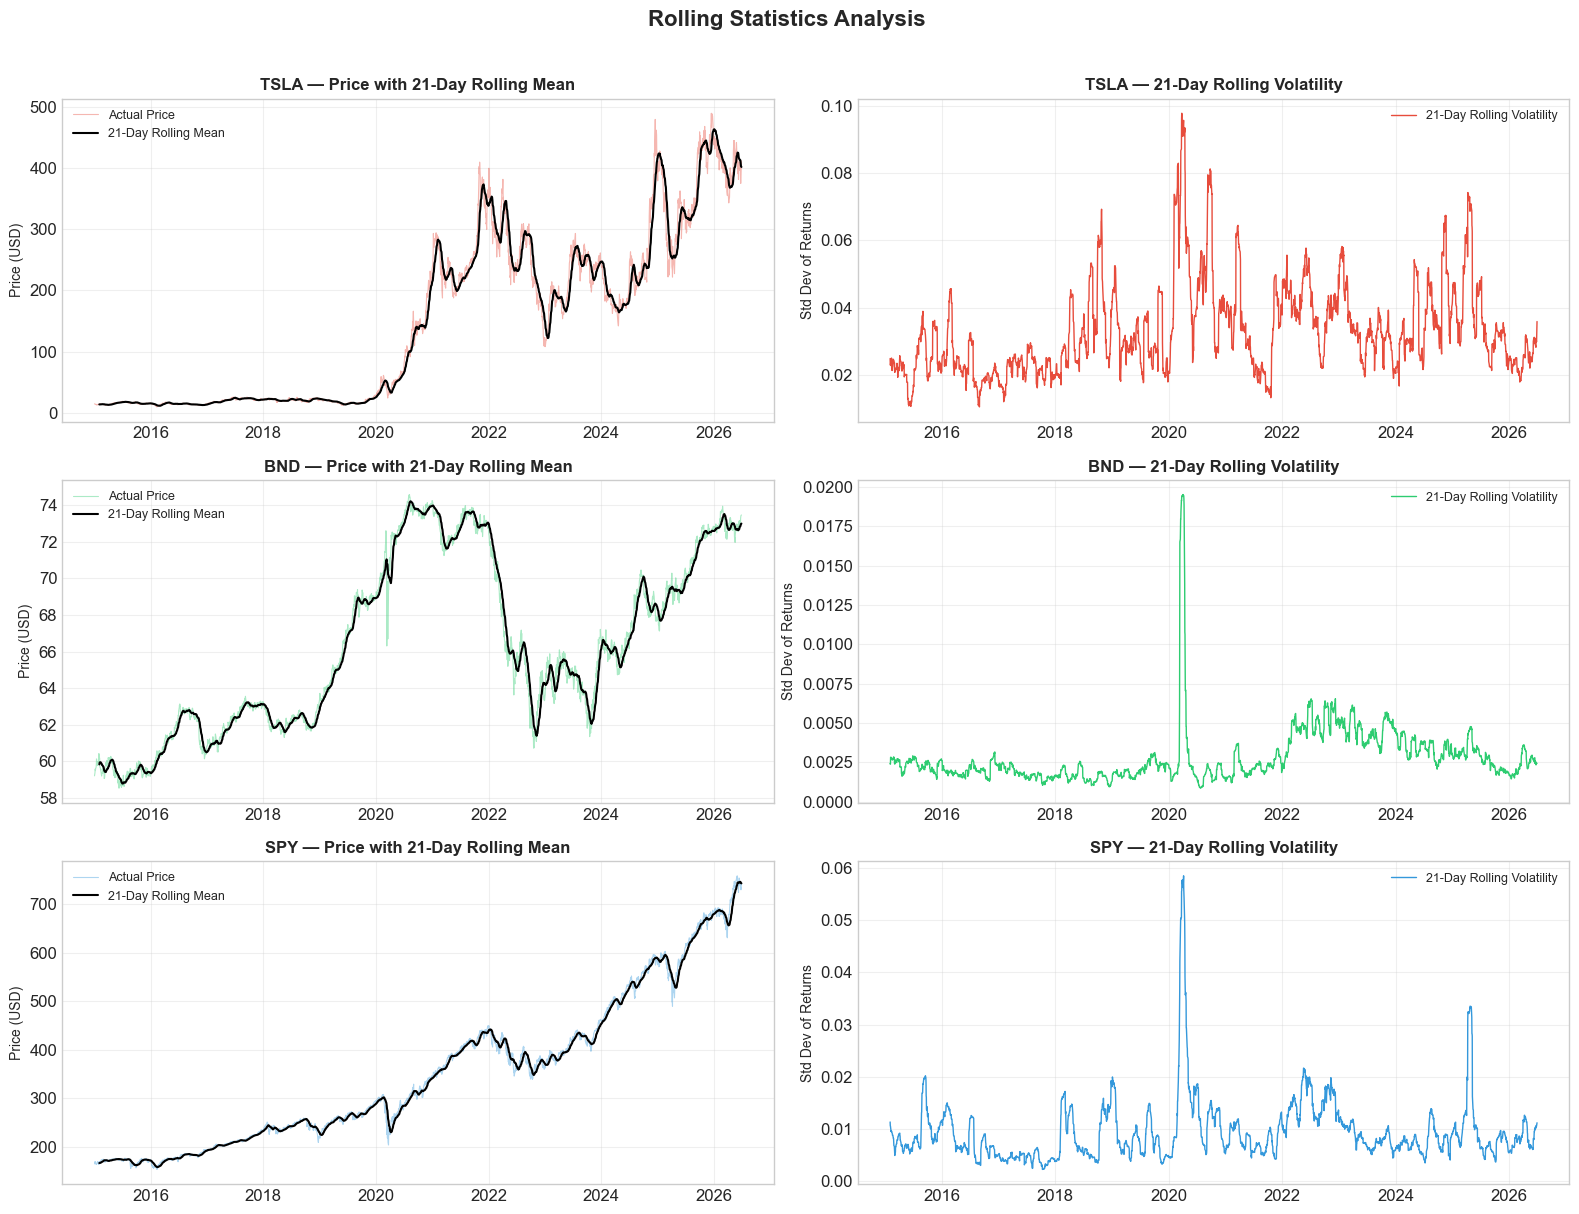

In [13]:
plot_rolling_statistics(close_prices_clean, daily_returns, tickers, window=21)

### 4.4 Outlier Detection
Identifying days with unusually extreme returns using the Z-score method (threshold = 3 standard deviations).

In [14]:
z_scores, outlier_summary = detect_outliers(daily_returns, tickers, z_threshold=3)


OUTLIERS FOR TSLA (|z-score| > 3)
Number of outlier days: 46

Most negative (worst days):
Ticker          TSLA
Date                
2020-09-08 -0.210628
2020-03-16 -0.185778
2020-02-05 -0.171758
2020-03-18 -0.160344
2025-03-10 -0.154262

Most positive (best days):
Ticker          TSLA
Date                
2020-03-19  0.183877
2021-03-09  0.196412
2020-02-03  0.198949
2024-10-24  0.219190
2025-04-09  0.226900

OUTLIERS FOR BND (|z-score| > 3)
Number of outlier days: 33

Most negative (worst days):
Ticker           BND
Date                
2020-03-12 -0.054384
2020-03-18 -0.024140
2020-03-17 -0.020685
2020-03-11 -0.018939
2022-06-13 -0.016153

Most positive (best days):
Ticker           BND
Date                
2022-09-28  0.015544
2020-03-20  0.016955
2022-11-10  0.020702
2020-03-23  0.022149
2020-03-13  0.042200

OUTLIERS FOR SPY (|z-score| > 3)
Number of outlier days: 39

Most negative (worst days):
Ticker           SPY
Date                
2020-03-16 -0.109424
2020-03-12 -0.095677
2

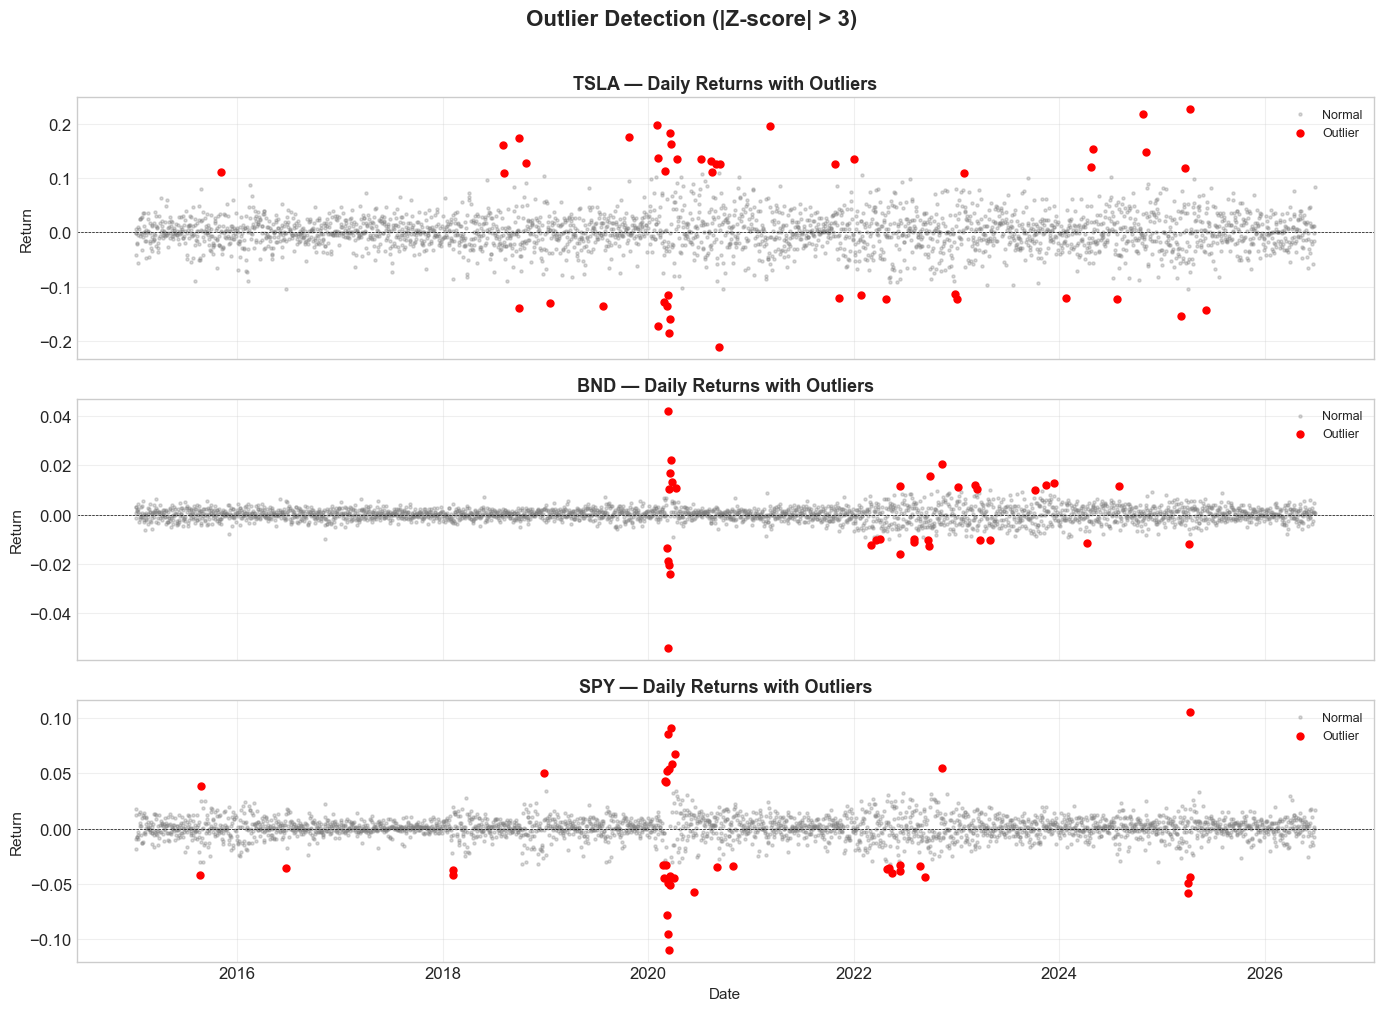

In [15]:
plot_outliers(daily_returns, z_scores, tickers, z_threshold=3)

## 5. Stationarity Testing (ADF)

**Augmented Dickey-Fuller Test:**
- **H₀ (Null):** Series is NOT stationary
- **p < 0.05** → Reject H0 → Series IS stationary 
- **p ≥ 0.05** → Fail to reject → NOT stationary 

In [16]:
adf_results = run_adf_for_all(close_prices_clean, daily_returns, tickers)
print("\nSUMMARY TABLE:")
adf_results

ADF TEST ON CLOSING PRICES
--- TSLA Close Price ---
  Test Statistic : -1.0696
  P-Value        : 0.727042
  Critical Values:
    1%: -3.4326
    5%: -2.8626
    10%: -2.5673
NOT STATIONARY (p=0.727042 >= 0.05)

--- BND Close Price ---
  Test Statistic : -1.0479
  P-Value        : 0.735408
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
NOT STATIONARY (p=0.735408 >= 0.05)

--- SPY Close Price ---
  Test Statistic : 1.3089
  P-Value        : 0.996659
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
NOT STATIONARY (p=0.996659 >= 0.05)

ADF TEST ON DAILY RETURNS
--- TSLA Daily Returns ---
  Test Statistic : -53.9719
  P-Value        : 0.000000
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
STATIONARY (p=0.000000 < 0.05)

--- BND Daily Returns ---
  Test Statistic : -15.2212
  P-Value        : 0.000000
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
STATIONARY (p=0.000000 < 0.05)

--- SPY Daily Returns ---
  Te

,Series,Test Statistic,P-Value,Stationary
0,TSLA Close Price,-1.0696,0.727042,False
1,BND Close Price,-1.0479,0.735408,False
2,SPY Close Price,1.3089,0.996659,False
3,TSLA Daily Returns,-53.9719,0.000000,True
4,BND Daily Returns,-15.2212,0.000000,True
5,SPY Daily Returns,-17.5722,0.000000,True


### Stationarity Results Interpretation

**Closing Prices** → All three assets are **NOT stationary** (p-value > 0.05).
This is expected because prices have a long-term trend (they go up over time).

**Daily Returns** → All three assets **ARE stationary** (p-value < 0.05).
Returns fluctuate around zero with no long-term trend.

**Implication for ARIMA:** Since closing prices are non-stationary, we will need
**first-order differencing (d=1)** to make the series stationary before applying ARIMA.

## 6. Risk Metrics

In [17]:
print("VALUE AT RISK (Historical Method)")
print("=" * 50)
var_table = calculate_var(daily_returns, tickers)
var_table

VALUE AT RISK (Historical Method)


,Asset,Confidence,VaR (Daily),Interpretation
0,TSLA,95%,-0.0517,"On 95% of days, TSLA won't lose more than 5.17%"
1,TSLA,99%,-0.0899,"On 99% of days, TSLA won't lose more than 8.99%"
2,BND,95%,-0.0048,"On 95% of days, BND won't lose more than 0.48%"
3,BND,99%,-0.0086,"On 99% of days, BND won't lose more than 0.86%"
4,SPY,95%,-0.0167,"On 95% of days, SPY won't lose more than 1.67%"
5,SPY,99%,-0.0317,"On 99% of days, SPY won't lose more than 3.17%"


In [18]:
print("SHARPE RATIO ANALYSIS")
print("=" * 50)
print(f"Risk-free rate: 2.0% | Trading days: 252")
print()
sharpe_table = calculate_sharpe_ratio(daily_returns, tickers)
sharpe_table

SHARPE RATIO ANALYSIS
Risk-free rate: 2.0% | Trading days: 252



,Annual Return,Annual Volatility,Sharpe Ratio
Asset,,,
TSLA,45.42%,57.18%,0.7595
BND,2.03%,5.31%,0.0047
SPY,14.43%,17.65%,0.7042


## 7. Key Insights and Summary

### Data Quality
- The dataset contains 2,888 trading days from Jan 2, 2015, to June 29, 2026. No missing values were found (0%), indicating high data completeness for all three assets.

### Price Trends
- **TSLA**: Showed massive growth but extreme volatility. Prices ranged from $9.58 to $489.88, with a mean of $148.77.
- **BND**: Remained highly stable, trading within a tight range of $58.53 to $74.58.
- **SPY**: Exhibited strong and consistent growth, reflecting the overall upward trend of the US market (ranging from $154.16 to $757.62).

### Volatility
- TSLA is by far the most volatile asset, with a daily return standard deviation of 3.6% and annual volatility of 57.18%. SPY has moderate volatility (1.11% daily std, 17.65% annual). BND is the least volatile (0.33% daily std, 5.31% annual).

### Outliers
- **TSLA** had 46 extreme outlier days (|z-score| > 3), with massive single-day drops (e.g., -21% on Sept 8, 2020) and gains (e.g., +22.6% on April 9, 2025). 
- **SPY** had 39 outlier days, heavily clustered around the March 2020 COVID-19 crash.
- **BND** had 33 outlier days, though the absolute magnitude of its price swings was much smaller.

### Stationarity
- Augmented Dickey-Fuller (ADF) tests confirm that the raw closing prices for all assets are **non-stationary** (p > 0.05). 
- However, their daily returns are strictly **stationary** (p ≈ 0.00), meaning I will need to use first-order differencing (d=1) when building ARIMA models.

### Risk Metrics
- **Value at Risk (VaR 95%)**: On 95% of days, TSLA won't lose more than 5.17%, SPY won't lose more than 1.67%, and BND won't lose more than 0.48%.
- **Sharpe Ratio**: TSLA has the highest Sharpe Ratio (0.7595) driven by its huge annualized return (45.42%). SPY follows closely (0.7042, with 14.43% return). BND has a near-zero Sharpe Ratio (0.0047), reflecting its low returns above the 2% risk-free rate.